# Partie 3 : Classification Multi-Modale Optimisée (S1 + S2 + Covariables)



In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Root Configuration
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "partie3":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "partie3"))

from partie3.mctnet_v2_model import build_mctnet_v2
print("TensorFlow version:", tf.__version__)
print("PROJECT_ROOT:", PROJECT_ROOT)

TensorFlow version: 2.21.0
PROJECT_ROOT: c:\Users\pc\Desktop\partie2


## 1. Préparation des données (Acquisition Sentinel-1)


In [2]:
# Chargement aligné (jointure sur `id` + tenseur S1 par mois : ratio, VH, VV)
from partie3.multimodal_data import load_aligned_multimodal

X_s2, X_s1, X_static, y, meta_align = load_aligned_multimodal(PROJECT_ROOT)
print(f"S2 Shape: {X_s2.shape}")
print(f"S1 Shape: {X_s1.shape}")
print(f"Static Shape: {X_static.shape}")
print(f"Unique labels: {np.unique(y)}")
print(f"Alignement (aperçu id): {meta_align.head(3).to_string()}")

S2 Shape: (16747, 3, 11)
S1 Shape: (16747, 12, 3)
Static Shape: (16747, 10)
Unique labels: [0 1 2 3 4]
Alignement (aperçu id):    id
0   0
1   1
2   2


## 2. Construction de l'Architecture Multi-Branche MCTNet-v2

In [3]:
N_CLASSES = 5
model = build_mctnet_v2(
    n_timesteps_s2=X_s2.shape[1],
    n_channels_s2=X_s2.shape[2],
    n_timesteps_s1=X_s1.shape[1],
    n_channels_s1=X_s1.shape[2],
    n_classes=N_CLASSES,
    n_static_features=X_static.shape[1],
    d_model=48,
    num_heads=6,
    n_stage=2
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\pc\Desktop\partie2\.venv\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Model: "mctnet_v2_multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ s2_input            │ (None, 3, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_stem (Conv1D)    │ (None, 3, 48)     │        576 │ s2_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_stem_bn          │ (None, 3, 48)     │        192 │ s2_stem[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_gap           │ (None, 48)        │          0 │ s2_stem_bn[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_dense1        │ (None, 6)         │        294 │ s2_se_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_dense2        │ (None, 48)        │        336 │ s2_se_dense1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 3)         │          0 │ s2_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_reshape       │ (None, 1, 48)     │          0 │ s2_se_dense2[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ensure_one_valid_t… │ (None, 3)         │          0 │ lambda[0][0]      │
│ (EnsureOneValidTim… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_input            │ (None, 12, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_scale         │ (None, 3, 48)     │          0 │ s2_stem_bn[0][0], │
│ (Multiply)          │                   │            │ s2_se_reshape[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ build_self_attenti… │ (None, 3, 3)      │          0 │ ensure_one_valid… │
│ (BuildSelfAttentio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 12)        │          0 │ s1_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion           │ (None, 3, 48)     │     43,433 │ s2_se_scale[0][0… │
│ (CTFusion)          │                   │            │ ensure_one_valid… │
│                     │                   │            │ build_self_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_stem (Conv1D)    │ (None, 12, 48)    │        192 │ s1_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ensure_one_valid_t… │ (None, 12)        │          0 │ lambda_1[0][0]    │
│ (EnsureOneValidTim… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_1         │ (None, 3, 48)     │     43,433 │ ct_fusion[0][0],  │
│ (CTFusion)          │                   │            │ ensure_one_valid… │
│                     │                   │            │ build_self_atten… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 221,039 (863.43 KB)

 Trainable params: 219,887 (858.93 KB)

 Non-trainable params: 1,152 (4.50 KB)

## 3. Entraînement et Stratégie d'Ablation


In [4]:
# Callbacks optimisés
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

# Split train/val (données déjà alignées dans load_aligned_multimodal)
indices = np.arange(len(y))
np.random.shuffle(indices)
split = int(0.8 * len(indices))

X_train = [X_s2[indices[:split]], X_s1[indices[:split]], X_static[indices[:split]]]
y_train = y[indices[:split]]

X_val = [X_s2[indices[split:]], X_s1[indices[split:]], X_static[indices[split:]]]
y_val = y[indices[split:]]

print("Starting training MCTNet-v2...")
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Starting training MCTNet-v2...
Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.8152 - loss: 0.5657 - val_accuracy: 0.7469 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8802 - loss: 0.3734 - val_accuracy: 0.8403 - val_loss: 0.4335 - learning_rate: 0.0010
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9033 - loss: 0.3201 - val_accuracy: 0.9128 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9136 - loss: 0.2824 - val_accuracy: 0.8958 - val_loss: 0.3126 - learning_rate: 0.0010
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9213 - loss: 0.2582 - val_accuracy: 0.8361 - val_loss: 0.5152 - learning_rate: 0.0010
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9251 - loss: 0.2408 - val_accuracy: 0.7770 - val_loss: 0.8903 - learning_rate: 0.0010
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/st

## 4. Visualisation des résultats


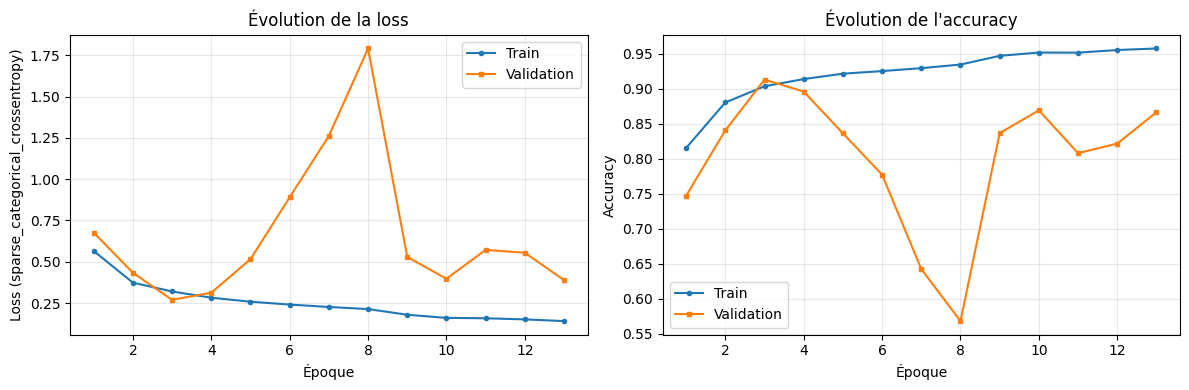

c:\Users\pc\Desktop\partie2\.venv\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Validation — loss: 0.2697  accuracy: 0.9128
F1 macro: 0.8099  F1 weighted: 0.9095

Rapport de classification (validation) :

              precision    recall  f1-score   support

    Maïs (0)     0.8931    0.7136    0.7933       199
   Coton (1)     0.8812    0.6380    0.7402       221
    Soja (2)     0.6963    0.7112    0.7037       187
     Riz (3)     0.9927    0.7598    0.8608       179
  Autres (4)     0.9271    0.9774    0.9516      2564

    accuracy                         0.9128      3350
   macro avg     0.8781    0.7600    0.8099      3350
weighted avg     0.9127    0.9128    0.9095      3350



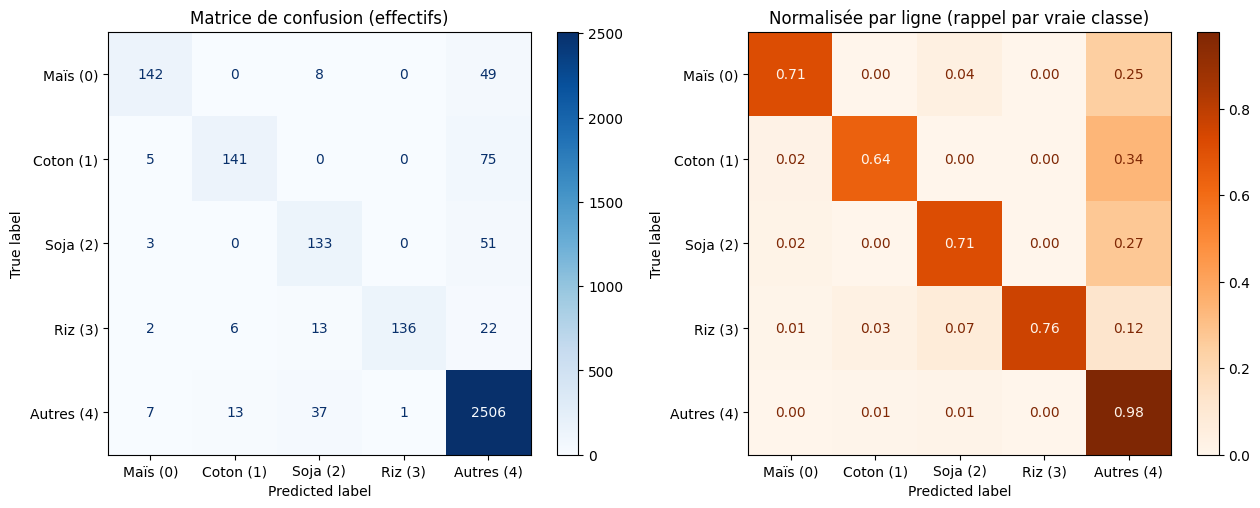

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

CLASS_NAMES = ["Maïs (0)", "Coton (1)", "Soja (2)", "Riz (3)", "Autres (4)"]

# --- Courbes d'entraînement ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs, history.history["loss"], label="Train", marker="o", markersize=3, linewidth=1.5)
axes[0].plot(epochs, history.history["val_loss"], label="Validation", marker="s", markersize=3, linewidth=1.5)
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss (sparse_categorical_crossentropy)")
axes[0].set_title("Évolution de la loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history.history["accuracy"], label="Train", marker="o", markersize=3, linewidth=1.5)
axes[1].plot(epochs, history.history["val_accuracy"], label="Validation", marker="s", markersize=3, linewidth=1.5)
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Évolution de l'accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Prédictions sur la validation (même split que fit) ---
y_proba = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_proba, axis=-1)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
macro_f1 = f1_score(y_val, y_pred, average="macro")
weighted_f1 = f1_score(y_val, y_pred, average="weighted")

print(f"Validation — loss: {val_loss:.4f}  accuracy: {val_acc:.4f}")
print(f"F1 macro: {macro_f1:.4f}  F1 weighted: {weighted_f1:.4f}\n")
print("Rapport de classification (validation) :\n")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4))

# --- Matrices de confusion ---
cm = confusion_matrix(y_val, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp_cnt = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp_cnt.plot(ax=axes[0], cmap="Blues", colorbar=True)
axes[0].set_title("Matrice de confusion (effectifs)")

row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sum, out=np.zeros_like(cm, dtype=float), where=row_sum != 0)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], cmap="Oranges", colorbar=True, values_format=".2f")
axes[1].set_title("Normalisée par ligne (rappel par vraie classe)")

plt.tight_layout()
plt.show()